In [2]:
pip install lasio

Note: you may need to restart the kernel to use updated packages.


In [3]:
#can also install what seems like a similar package through conda --> conda install ziebel::lasio

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import lasio

In [5]:
caliper = lasio.read("Parish886189_CALIPER_4-22-2025.las")

In [6]:
caliper.sections.keys()

dict_keys(['Version', 'Well', 'Curves', 'Parameter', 'Other'])

In [7]:
caliper.sections['Version']

[HeaderItem(mnemonic="VERS", unit="", value="2.0", descr="CWLS LOG ASCII STANDA"),
 HeaderItem(mnemonic="WRAP", unit="", value="NO", descr="ONE LINE PER DEPTH STE")]

In [8]:
for item in caliper.sections['Well']:
    print(f"{item.descr} ({item.mnemonic}): \t\t {item.value}")

FIRST INDEX VALUE (STRT): 		 4.2296
LAST INDEX VALUE (STOP): 		 269.254
STEP (STEP): 		 0.0
NULL VALUE (NULL): 		 -99999
 (COMP): 		 
WELL (WELL): 		 CARLTON (DARCY TW)
 (FLD): 		 
 (LOC): 		 
 (SRVC): 		 
CTRY (CTRY): 		 USA
STAT (STAT): 		 MINNESOTA
CNTY (CNTY): 		 RICE
DATE (DATE): 		 04/22/2025
API (API): 		 886189


In [9]:
for curve in caliper.curves:
    print(curve.mnemonic)

DEPT
CALIPER-IN
TIME
TCPU
MOTOR
CALIPER-CM
OPEN
CLOSE
ARM
SPEED
TOOLPOWERVOLTAGE
TOOLPOWERCURRENT


In [10]:
for count, curve in enumerate(caliper.curves):
    print(f"Curve: {curve.mnemonic}, \t Units: {curve.unit}, \t Description: {curve.descr}")
print(f"There are a total of: {count+1} curves present within this file")

Curve: DEPT, 	 Units: FT, 	 Description: DEPTH
Curve: CALIPER-IN, 	 Units: IN, 	 Description: Caliper-In
Curve: TIME, 	 Units: SEC, 	 Description: Time
Curve: TCPU, 	 Units: 'C, 	 Description: TCPU
Curve: MOTOR, 	 Units: , 	 Description: Motor
Curve: CALIPER-CM, 	 Units: CM, 	 Description: Caliper-Cm
Curve: OPEN, 	 Units: , 	 Description: Open
Curve: CLOSE, 	 Units: , 	 Description: Close
Curve: ARM, 	 Units: , 	 Description: Arm
Curve: SPEED, 	 Units: FT/MIN, 	 Description: Speed
Curve: TOOLPOWERVOLTAGE, 	 Units: V, 	 Description: ToolPowerVoltage
Curve: TOOLPOWERCURRENT, 	 Units: MA, 	 Description: ToolPowerCurrent
There are a total of: 12 curves present within this file


In [11]:
callog = caliper.df()

In [12]:
callog

,CALIPER-IN,TIME,TCPU,MOTOR,CALIPER-CM,OPEN,CLOSE,ARM,SPEED,TOOLPOWERVOLTAGE,TOOLPOWERCURRENT
DEPT,,,,,,,,,,,
4.2296,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.3936,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.5576,6.24631,NaN,NaN,NaN,15.7852,NaN,NaN,NaN,NaN,NaN,NaN
4.7216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.8856,6.24631,0.368,20.1325,128.0,15.7852,0.0,1.0,-1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
268.5980,NaN,1.068,20.7842,128.0,NaN,0.0,1.0,-1.0,19.40930,118.000,15.1351
268.7620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.35700,118.787,15.1351
268.9260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.06490,119.000,15.1351


In [13]:
callog.describe()

,CALIPER-IN,TIME,TCPU,MOTOR,CALIPER-CM,OPEN,CLOSE,ARM,SPEED,TOOLPOWERVOLTAGE,TOOLPOWERCURRENT
count,1402.000000,1402.000000,1402.000000,1402.0,1402.000000,1402.0,1402.0,1402.0,1609.000000,1609.000000,1609.000000
mean,6.278404,0.549965,20.280432,128.0,15.865432,0.0,1.0,-1.0,18.023727,118.396506,19.508299
std,0.312311,0.042045,0.185920,0.0,0.780328,0.0,0.0,0.0,1.933261,11.446244,4.403006
min,6.060730,0.334002,20.132500,128.0,15.325400,0.0,1.0,-1.0,8.851610,0.000000,0.000000
25%,6.094470,0.553003,20.132500,128.0,15.409000,0.0,1.0,-1.0,17.552500,119.000000,16.216200
50%,6.232045,0.557247,20.142100,128.0,15.749900,0.0,1.0,-1.0,17.634500,119.695000,19.459500
75%,6.341000,0.560932,20.349800,128.0,16.019875,0.0,1.0,-1.0,17.798600,120.139000,23.783800
max,10.285900,1.068000,20.784200,128.0,26.122600,0.0,1.0,-1.0,29.363500,121.000000,25.945900


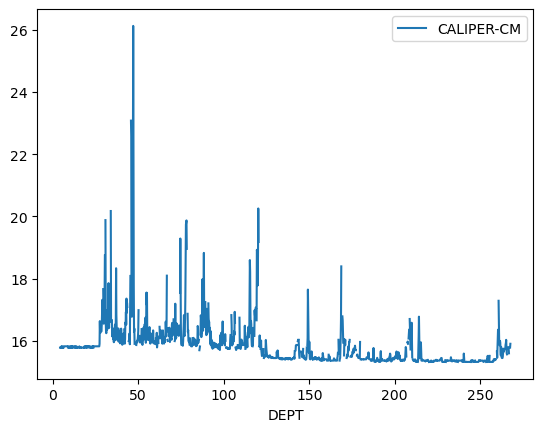

In [14]:
callog.plot(y = "CALIPER-CM");

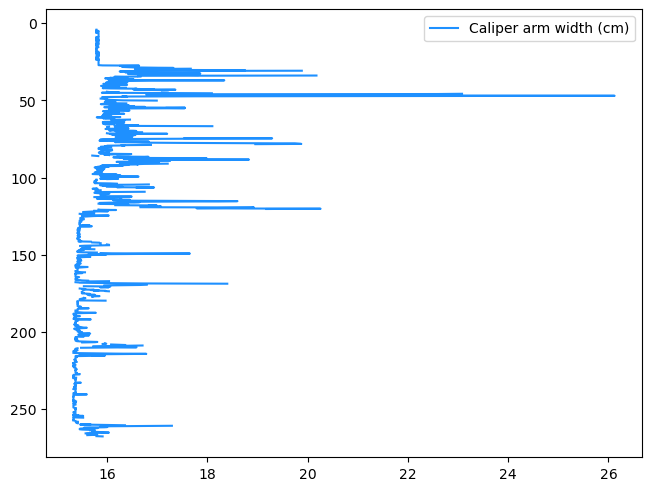

In [15]:
fig, ax = plt.subplots(layout = 'constrained')
plt.plot(callog.loc[:, "CALIPER-CM"], callog.index, label = "Caliper arm width (cm)", color = "dodgerblue")
ax.invert_yaxis()


plt.legend()

plt.show()

In [16]:
#parsing the xml file for April 10, 2026

In [17]:
import xml.etree.ElementTree as ET
tree = ET.parse('channel 1_UTC_20260410_155519.270.xml')
root = tree.getroot()

In [18]:
print(root)

<Element '{http://www.witsml.org/schemas/1series}logs' at 0x000002A2B5668770>


In [26]:
# april10 = pd.read_xml('channel 1_UTC_20260410_155519.270.xml')
# april10

,uid,nameWell,nameWellbore,name,indexType,startIndex,endIndex,stepIncrement,startDateTimeIndex,endDateTimeIndex,direction,indexCurve,logCurveInfo,logData,customData
0,measurement,XT16042,NaN,Log config:DarcyTestWell_12min_contin channel:...,length,-225.374,221.509,0.254,2026-04-10T15:55:19.270Z,2026-04-10T16:07:19.952Z,increasing,LAF,\n,\n,\n


In [22]:
# pd.read_xml("channel 1_UTC_20260410_155519.270.xml")
# data = []
# for data in root.findall('data'):
#     row = {child.tag: child.text for child in data}
#     data.append(row)
# print(data)

[]


In [21]:
# april10  = pd.DataFrame(data)
# print(april10)

Empty DataFrame
Columns: []
Index: []


In [24]:
# april10 = tree.DataFrame()

AttributeError: 'ElementTree' object has no attribute 'DataFrame'